In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import scipy
import pickle
import solvers
import sde
import dnnlib

torch.manual_seed(42)

In [2]:
with dnnlib.util.open_url("model/edm2-img512-s-2147483-0.120.pkl") as f:
    model = pickle.load(f)["ema"].to("cuda")

In [3]:
noise = torch.randn((8, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((8, 1)).to("cuda")

In [4]:
noise.shape

torch.Size([8, 4, 64, 64])

In [5]:
sde_ = sde.LinearVariancePreservingSDE(beta_min=0.1, beta_max=20).to("cuda")
rsde = sde_.get_reverse_sde(model).to("cuda")

In [6]:
n_steps = 20
discretisation = torch.linspace(1, 0, n_steps)
pi_solver = solvers.PISolver(
    rsde,
    ki=0.101, 
    kp=0.09, 
    tau=0.42668694, 
    alpha=0.8,
    h_start=0.01,
    max_decrease=0.7,
    max_increase=1.20
).to("cuda")

x_em = pi_solver.solve(noise.clone())

RuntimeError: The size of tensor a (8) must match the size of tensor b (64) at non-singleton dimension 3

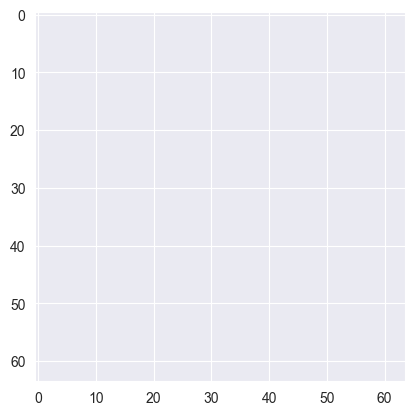

In [12]:
plt.imshow(x_em[0, 0:3, :, :].cpu().T)